In [10]:
from pathlib import Path

import pandas as pd
from plots import plot_b

In [11]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[-1]


def earliest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[0]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))]
        for k, v in splits
        if k != "unknown"
    }

In [12]:
training_data_route = Path("../../tmp/foundation/experiment_b")

target_schedules = pd.read_csv(training_data_route / "nts_activities_2024.csv")
target_attributes = pd.read_csv(training_data_route / "nts_attributes_2024.csv")

training_attributes = {
    "uk": pd.read_csv(training_data_route / "uk_attributes.csv"),
    "uk+aus": pd.read_csv(training_data_route / "uk+aus_attributes.csv"),
    "western": pd.read_csv(training_data_route / "west_attributes.csv"),
    "world": pd.read_csv(training_data_route / "world_attributes.csv"),
}

training_schedules = {
    "uk": pd.read_csv(training_data_route / "uk_activities.csv"),
    "uk+aus": pd.read_csv(training_data_route / "uk+aus_activities.csv"),
    "western": pd.read_csv(training_data_route / "west_activities.csv"),
    "world": pd.read_csv(training_data_route / "world_activities.csv"),
}

/tmp/ipykernel_894204/3094319490.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  "world": pd.read_csv(training_data_route / "world_attributes.csv"),


In [13]:
counter = {}
# load each and get counts per source
counter["baseline"] = target_attributes.source.value_counts()
for name, data in training_attributes.items():
    print(data.source.unique())
    counter[name] = data.source.value_counts()
df = pd.DataFrame(counter)


order = ["ktdb", "ltds", "vista", "qhts", "nhts", "nts"]
df = df.loc[order].fillna(0)
totals = df.sum()
totals_row = pd.DataFrame([totals], index=["Total"])
df = pd.concat([df, totals_row])
print(df.to_latex(float_format="{:.0f}".format))

['ltds' 'nts']
['ltds' 'vista' 'qhts' 'nts']
['ltds' 'vista' 'qhts' 'nhts' 'nts']
['ktdb' 'ltds' 'vista' 'qhts' 'nhts' 'nts']
\begin{tabular}{lrrrrr}
\toprule
 & baseline & uk & uk+aus & western & world \\
\midrule
ktdb & 0 & 0 & 0 & 0 & 90798 \\
ltds & 0 & 25812 & 25812 & 25812 & 25812 \\
vista & 0 & 0 & 11014 & 11014 & 11014 \\
qhts & 0 & 0 & 23271 & 23271 & 23271 \\
nhts & 0 & 0 & 0 & 8623 & 8623 \\
nts & 69826 & 69826 & 69826 & 69826 & 69826 \\
Total & 69826 & 95638 & 129923 & 138546 & 229344 \\
\bottomrule
\end{tabular}



In [14]:
def distance_table(batch_path, suffix=""):
    df = pd.read_csv(batch_path / f"domain_distances{suffix}.csv").set_index(
        "domain"
    )
    order = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]
    print(df.loc[order].to_latex(float_format="{:.3f}".format))
    return df.loc[order]


df = distance_table(Path("../../logs/foundations/B"), suffix="")

df

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & uk & uk+aus & west & world \\
domain &  &  &  &  &  &  \\
\midrule
participations & 1.484 & 0.059 & 0.065 & 0.070 & 0.082 & 0.070 \\
transitions & 0.018 & 0.003 & 0.003 & 0.006 & 0.009 & 0.007 \\
timing & 0.444 & 0.023 & 0.022 & 0.056 & 0.066 & 0.060 \\
feasibility & 0.020 & 0.032 & 0.029 & 0.025 & 0.087 & 0.031 \\
creativity & 0.218 & 0.013 & 0.018 & 0.009 & 0.010 & 0.010 \\
\bottomrule
\end{tabular}



,observed,baseline,uk,uk+aus,west,world
domain,,,,,,
participations,1.483559,0.059019,0.065284,0.070397,0.081629,0.069933
transitions,0.017727,0.003324,0.002858,0.005619,0.008994,0.006825
timing,0.444189,0.022615,0.022312,0.055899,0.065911,0.060041
feasibility,0.019878,0.032118,0.028745,0.024768,0.087081,0.030543
creativity,0.217920,0.013297,0.017834,0.009344,0.009931,0.010208


In [15]:
df_alt = distance_table(Path("../../logs/foundations/B_alt"), suffix="")
diff = 100 * (df - df_alt) / df_alt
order = ["participations", "transitions", "timing", "feasibility", "creativity"]
print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))
diff

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & uk & uk+aus & west & world \\
domain &  &  &  &  &  &  \\
\midrule
participations & 1.484 & 0.046 & 0.062 & 0.068 & 0.066 & 0.087 \\
transitions & 0.018 & 0.003 & 0.005 & 0.008 & 0.006 & 0.007 \\
timing & 0.444 & 0.024 & 0.029 & 0.051 & 0.048 & 0.053 \\
feasibility & 0.020 & 0.040 & 0.037 & 0.018 & 0.031 & 0.037 \\
creativity & 0.218 & 0.017 & 0.013 & 0.010 & 0.009 & 0.009 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrr}
\toprule
 & observed & baseline & uk & uk+aus & west & world \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.0\% & 29.0\% & 5.4\% & 3.3\% & 23.0\% & -20.0\% \\
transitions & 0.0\% & 6.3\% & -42.1\% & -26.2\% & 50.7\% & 2.1\% \\
timing & 0.0\% & -7.5\% & -23.8\% & 10.4\% & 36.5\% & 13.8\% \\
feasibility & 0.0\% & -19.4\% & -21.8\% & 39.8\% & 178.1\% & -17.4\% \\
creativity & 0.0\% & -20.8\% & 35.0\% & -2.6\% & 6.9\% & 19.5\% \\
\bottomrule
\end{tabular}



<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_894204/800181396.py:4: SyntaxWarning: invalid escape sequence '\%'
  print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))


,observed,baseline,uk,uk+aus,west,world
domain,,,,,,
participations,0.0,28.983422,5.433212,3.252491,22.957289,-19.971172
transitions,0.0,6.294249,-42.137007,-26.244243,50.651683,2.069858
timing,0.0,-7.538840,-23.837201,10.351550,36.460373,13.768833
feasibility,0.0,-19.357703,-21.846696,39.783787,178.091820,-17.403866
creativity,0.0,-20.794183,35.014847,-2.623066,6.941204,19.497730


In [16]:
# _ = plot_b(
#     training_schedules, training_attributes, target_schedules, target_attributes
# )

In [17]:
batch_root = Path("../../logs/foundations/B")

batch_paths = {
    "B0 (baseline)": batch_root / "baseline",
    "B1 (UK)": batch_root / "uk",
    "B2 (UK+AUS)": batch_root / "uk+aus",
    "B3 (West)": batch_root / "west",
    "B4 (World)": batch_root / "world",
}

# find data
data_root = Path("../../tmp/foundation")
target_schedules = pd.read_csv(
    data_root / "experiment_b" / "nts_activities_2024.csv"
)
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    data_root / "experiment_b" / "nts_attributes_2024.csv"
)

schedules = {
    n: pd.read_csv(latest(p)[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(latest(p)[1], default=target_attributes)
    for n, p in batch_paths.items()
}
print(schedules.keys())
print(attributes.keys())

Found versions for baseline: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/baseline/version_2
Found versions for uk: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/uk/version_2
Found versions for uk+aus: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/uk+aus/version_2
Found versions for west: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/west/version_2
Found versions for world: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/world/version_2
Found versions for baseline: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/baseline/version_2
Loading synthetic attributes from ../../logs/foundations/B/baseline/version_2
Found versions for uk: ['version_0', 'version_1', 'version_2']. Returning ../../logs/foundations/B/uk/version_2
Loading synthetic attributes from ../../logs/foundations/B/uk/version_2
Found versions for uk+au

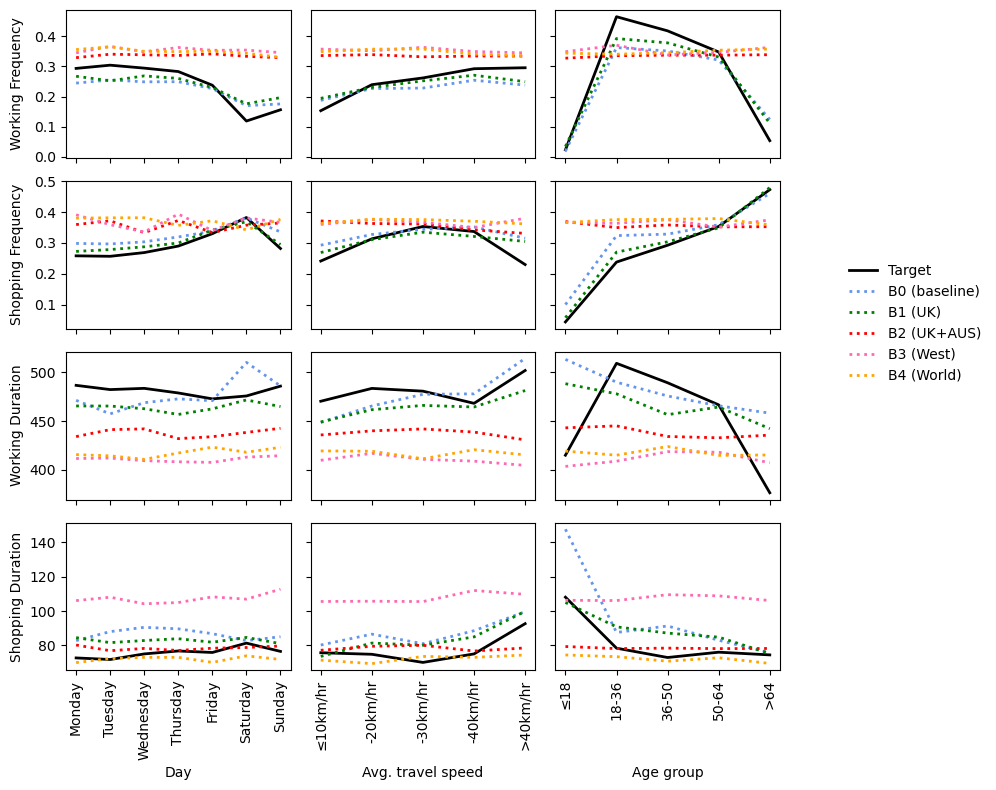

In [18]:
_ = plot_b(schedules, attributes, target_schedules, target_attributes)